In [35]:
import matplotlib.pyplot as plt

from script import run_superfv_sim
from superfv import RiemannSolver

In [36]:
def plot_fv(ax, sim):
    ax.set_aspect("equal")

    x_fv, y_fv, _ = sim.mesh.faces
    z_fv = sim.snapshot_history[-1].w[0, :, :, 0].T
    return ax.pcolormesh(x_fv, y_fv, z_fv)


def plot_sd(ax, sim):
    ax.set_aspect("equal")

    x_sd = sim.regular_faces()[0]
    y_sd = sim.regular_faces()[1]
    z_sd = sim.transpose_to_fv(sim.regular_mesh(sim.dm.W_cv))[0]
    return ax.pcolormesh(x_sd, y_sd, z_sd)

In [37]:
sim1 = run_superfv_sim("llf", 3, 320, rtol=1e-5, riemann_solver=RiemannSolver.LLF)
sim2 = run_superfv_sim("hllc", 3, 320, rtol=1e-5, riemann_solver=RiemannSolver.HLLC)
# sim3 = run_spd_sim("llf", 3, 320, tolerance=1e-5, riemann_solver_sd="llf", riemann_solver_fv="llf")
# sim4 = run_spd_sim("hllc", 3, 320, tolerance=1e-5, riemann_solver_sd="hllc", riemann_solver_fv="hllc")

Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_llf_NDOF=320_p=3/params.pkl: Can't get attribute 'post_shock_state' on <module '__main__'>
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_llf_NDOF=320_p=3'
Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_hllc_NDOF=320_p=3/params.pkl: Can't get attribute 'post_shock_state' on <module '__main__'>
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_hllc_NDOF=320_p=3'


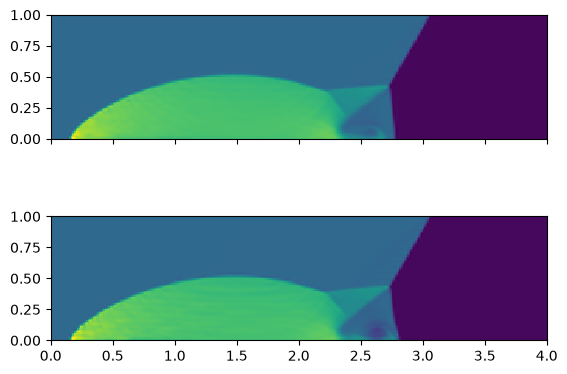

In [ ]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)

plot_fv(axs[0], sim1)
plot_fv(axs[1], sim2)
# plot_sd(axs[0], sim3)
# plot_sd(axs[1], sim4)